# 02 — Schema accuracy by sentence type, prompt, model, and schema

This notebook evaluates model performance using the correct usability flags. The GPT interpretation prompt now explicitly distinguishes naïve free-text baseline records from structured JSON records.

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, display

# Robust project-root detection: works when run from notebooks/ or project root.
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = DATA_DIR / "outputs"
PARSED_PATH = OUTPUT_DIR / "parsed_responses.jsonl"
RAW_PATH = OUTPUT_DIR / "raw_responses.jsonl"

# Optional .env loading for PyCharm/Jupyter server contexts that do not inherit shell exports.
try:
    from dotenv import load_dotenv
    load_dotenv(PROJECT_ROOT / ".env")
except ImportError:
    pass

def read_jsonl(path: Path) -> pd.DataFrame:
    records = []
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            if line.strip():
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError as exc:
                    raise ValueError(f"Invalid JSON in {path} line {line_no}: {exc}") from exc
    return pd.DataFrame(records)

def pct(x):
    if x is None or pd.isna(x):
        return "NA"
    return f"{100 * float(x):.1f}%"

def safe_accuracy(df: pd.DataFrame, pred_col: str, gold_col: str) -> float | None:
    if df.empty or pred_col not in df.columns or gold_col not in df.columns:
        return None
    sub = df[df[pred_col].notna() & df[gold_col].notna()].copy()
    if sub.empty:
        return None
    return float((sub[pred_col].astype(str) == sub[gold_col].astype(str)).mean())

def display_compact_df(df: pd.DataFrame, font_size: str = "10px", max_rows: int = 50):
    """Display a compact DataFrame with smaller notebook font."""
    if df is None:
        display(Markdown("_No DataFrame to display._"))
        return
    with pd.option_context("display.max_rows", max_rows, "display.max_columns", 100, "display.max_colwidth", 100):
        display(
            df.style.set_table_styles([
                {"selector": "th", "props": [
                    ("font-size", font_size),
                    ("padding", "3px 6px"),
                    ("white-space", "nowrap"),
                ]},
                {"selector": "td", "props": [
                    ("font-size", font_size),
                    ("padding", "3px 6px"),
                    ("white-space", "nowrap"),
                ]},
            ])
        )

HTML("""
<style>
.dataframe th, .dataframe td {
    font-size: 10px !important;
    padding: 3px 6px !important;
}
.output_area pre {
    font-size: 11px !important;
}
</style>
""")

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print("OPENAI_API_KEY loaded:", bool(os.getenv("OPENAI_API_KEY")))

PROJECT_ROOT = /Users/Shared/image_schema_llm_project
OPENAI_API_KEY loaded: True


In [2]:
# --- Optional GPT interpretation layer ---------------------------------------
# Set this to True when you want notebook cells to call the OpenAI API.
# Leave False for normal reproducible analysis without API calls.
ENABLE_GPT_INTERPRETATION = True

# Use a low-cost/current model available to your OpenAI API project.
# Change this to match the model enabled in your account, e.g. "gpt-5.4-mini".
INTERPRETATION_MODEL = os.getenv("INTERPRETATION_MODEL", "gpt-5.4-mini")

INTERPRETATION_CACHE_PATH = OUTPUT_DIR / "notebook_interpretations.json"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESEARCH_CONTEXT = """
This is a Computational Linguistics MA project evaluating whether structured
image-schema prompting improves LLM interpretation of literal spatial,
metaphorical spatial, and weak-schema control sentences.

Important parsing convention:
- The naive prompt family is intentionally free-text and should normally appear
  as parse_status == "free_text_unparsed".
- free_text_unparsed is not a parsing failure when prompt_family == "naive".
  It is the expected baseline behaviour for ordinary paraphrase/interpretation.
- Direct-schema and structured-role prompts are the structured JSON-producing
  prompt families.
- Parse quality should be evaluated separately for naive and structured prompts.
- For schema accuracy, use records where usable_for_schema_accuracy == True.
- For literal/metaphorical/control accuracy, use records where usable_for_lm_accuracy == True.
- Partial records may still be valid for selected metrics if the relevant
  usability flag is True.
- The project does not claim that LLMs possess embodied cognition; it tests
  whether image-schema prompting provides a useful intermediate representational
  layer beyond ordinary paraphrase.
"""

def load_interpretation_cache() -> dict:
    if INTERPRETATION_CACHE_PATH.exists():
        try:
            return json.loads(INTERPRETATION_CACHE_PATH.read_text(encoding="utf-8"))
        except json.JSONDecodeError:
            return {}
    return {}

def save_interpretation_cache(cache: dict) -> None:
    INTERPRETATION_CACHE_PATH.write_text(
        json.dumps(cache, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

interpretation_cache = load_interpretation_cache()

def df_to_compact_markdown(df: pd.DataFrame, max_rows: int = 20) -> str:
    if df is None or df.empty:
        return "No rows available."
    compact = df.copy()
    for col in compact.select_dtypes(include="number").columns:
        compact[col] = compact[col].round(4)
    if len(compact) > max_rows:
        compact = compact.head(max_rows)
    return compact.to_markdown(index=False)

def _openai_interpretation_call(prompt: str, model: str = INTERPRETATION_MODEL) -> str:
    try:
        from openai import OpenAI
    except ImportError as exc:
        raise RuntimeError("Install the OpenAI SDK with: python -m pip install openai") from exc

    if not os.getenv("OPENAI_API_KEY"):
        raise RuntimeError("OPENAI_API_KEY is not set. Add it to .env or export it before starting Jupyter.")

    client = OpenAI()
    response = client.responses.create(
        model=model,
        input=prompt,
    )
    return response.output_text

def interpret_result(
    result_df: pd.DataFrame,
    *,
    title: str,
    cache_key: str,
    research_context: str = RESEARCH_CONTEXT,
    max_rows: int = 20,
    force_refresh: bool = False,
) -> str | None:
    """
    Generate or retrieve a concise GPT interpretation for a result table.

    Output requested:
    - 3 to 5 concise bullet points
    - one short summarising paragraph
    - methodological caution where relevant
    """
    if not force_refresh and cache_key in interpretation_cache:
        return interpretation_cache[cache_key]

    if not ENABLE_GPT_INTERPRETATION:
        return None

    table_md = df_to_compact_markdown(result_df, max_rows=max_rows)

    prompt = f"""
You are helping interpret results from a Computational Linguistics MA project.

Project context:
{research_context}

Result title:
{title}

Results table:
{table_md}

Critical interpretation rules:
- Do not treat naive prompt free-text outputs as parse failures.
- If parse_status == "free_text_unparsed" occurs for prompt_family == "naive",
  describe this as expected baseline behaviour.
- Evaluate JSON conformity mainly for direct_schema and structured_role_based prompts.
- Distinguish raw-data quality, parsing coverage, and semantic accuracy.
- Do not overclaim embodied cognition in LLMs.
- If a table includes both all-prompt and structured-only parse results, explain
  why structured-only results are the correct basis for JSON parsing quality.
- If partial records are present, mention whether the usability flags still
  permit them to contribute to specific metrics.

Output requirements:
- Use 3 to 5 concise bullet points.
- Then add one short summarising paragraph.
- Mention any important methodological caution.
- Prefer precise wording such as "suggests", "indicates", "is consistent with".
- Keep the whole answer under 180 words.
"""
    text = _openai_interpretation_call(prompt)
    interpretation_cache[cache_key] = text
    save_interpretation_cache(interpretation_cache)
    return text

def display_gpt_interpretation(
    result_df: pd.DataFrame,
    *,
    title: str,
    cache_key: str,
    max_rows: int = 20,
    force_refresh: bool = False,
):
    """
    Display GPT interpretation below a result cell.
    If API calls are disabled and no cached interpretation exists, display a placeholder.
    """
    text = interpret_result(
        result_df,
        title=title,
        cache_key=cache_key,
        max_rows=max_rows,
        force_refresh=force_refresh,
    )

    if text is None:
        display(Markdown(
            f"### GPT interpretation: {title}\n\n"
            "_Disabled. Set `ENABLE_GPT_INTERPRETATION = True` and rerun this cell to generate concise bullet points and a summary paragraph._"
        ))
        return None

    display(Markdown(f"### GPT interpretation: {title}\n\n{text}"))
    return text

In [3]:
parsed = read_jsonl(PARSED_PATH)

schema_df = parsed[
    (parsed["usable_for_schema_accuracy"].fillna(False) == True)
    & parsed["expected_schema_primary"].notna()
    & parsed["main_image_schema"].notna()
].copy()

lm_df = parsed[
    (parsed["usable_for_lm_accuracy"].fillna(False) == True)
    & parsed["expected_literal_or_metaphorical"].notna()
    & parsed["literal_or_metaphorical"].notna()
].copy()

print(f"All parsed records: {len(parsed)}")
print(f"Schema-usable records: {len(schema_df)}")
print(f"LM-usable records: {len(lm_df)}")

All parsed records: 5400
Schema-usable records: 3569
LM-usable records: 3600


## Overall accuracy

In [4]:
overall = pd.DataFrame([
    {
        "metric": "primary_schema_accuracy",
        "n": len(schema_df),
        "accuracy": safe_accuracy(schema_df, "main_image_schema", "expected_schema_primary"),
    },
    {
        "metric": "literal_metaphorical_accuracy",
        "n": len(lm_df),
        "accuracy": safe_accuracy(lm_df, "literal_or_metaphorical", "expected_literal_or_metaphorical"),
    },
])
display_compact_df(overall)
display_gpt_interpretation(overall, title="Overall structured-output accuracy", cache_key="v2_02_overall_accuracy")

,metric,n,accuracy
0,primary_schema_accuracy,3569,0.766041
1,literal_metaphorical_accuracy,3600,0.769444


### GPT interpretation: Overall structured-output accuracy

- Across usable records, primary image-schema identification reached **0.766 accuracy** over **3,569** cases, indicating reasonably strong but imperfect schema assignment.
- Literal/metaphorical/control classification reached **0.7694 accuracy** over **3,600** usable cases, suggesting similar performance for the higher-level semantic distinction.
- These figures should be interpreted using the relevant usability flags: schema accuracy uses `usable_for_schema_accuracy == True`, while literal/metaphorical/control accuracy uses `usable_for_lm_accuracy == True`.
- Naive prompt outputs marked `free_text_unparsed` should not be counted as parsing failures; they are expected baseline free-text behaviour. JSON conformity should be assessed mainly for the direct-schema and structured-role prompt families.
- A methodological caution is that these results measure the usefulness of structured image-schema prompting as an intermediate representational layer, not evidence that the model possesses embodied cognition.

Overall, the results suggest that structured prompting supports moderately reliable schema and literal/metaphorical/control interpretation, while still leaving substantial room for error. Parsing quality, raw-data completeness, and semantic accuracy should be kept analytically separate.

'- Across usable records, primary image-schema identification reached **0.766 accuracy** over **3,569** cases, indicating reasonably strong but imperfect schema assignment.\n- Literal/metaphorical/control classification reached **0.7694 accuracy** over **3,600** usable cases, suggesting similar performance for the higher-level semantic distinction.\n- These figures should be interpreted using the relevant usability flags: schema accuracy uses `usable_for_schema_accuracy == True`, while literal/metaphorical/control accuracy uses `usable_for_lm_accuracy == True`.\n- Naive prompt outputs marked `free_text_unparsed` should not be counted as parsing failures; they are expected baseline free-text behaviour. JSON conformity should be assessed mainly for the direct-schema and structured-role prompt families.\n- A methodological caution is that these results measure the usefulness of structured image-schema prompting as an intermediate representational layer, not evidence that the model possess

## Accuracy by sentence type

In [5]:
schema_by_sentence = (
    schema_df.groupby("sentence_type")
    .apply(lambda g: pd.Series({
        "n_schema": len(g),
        "schema_accuracy": safe_accuracy(g, "main_image_schema", "expected_schema_primary"),
    }))
    .reset_index()
)

lm_by_sentence = (
    lm_df.groupby("sentence_type")
    .apply(lambda g: pd.Series({
        "n_lm": len(g),
        "literal_metaphorical_accuracy": safe_accuracy(g, "literal_or_metaphorical", "expected_literal_or_metaphorical"),
    }))
    .reset_index()
)

by_sentence_type = schema_by_sentence.merge(lm_by_sentence, on="sentence_type", how="outer")
display_compact_df(by_sentence_type)
display_gpt_interpretation(by_sentence_type, title="Accuracy by sentence type", cache_key="v2_02_accuracy_by_sentence_type")

,sentence_type,n_schema,schema_accuracy,n_lm,literal_metaphorical_accuracy
0,control_weak_schema,1172.000000,0.579352,1188.000000,0.309764
1,literal_spatial,1198.000000,0.808848,1206.000000,0.992537
2,metaphorical_spatial,1199.000000,0.905755,1206.000000,0.999171


### GPT interpretation: Accuracy by sentence type

- Schema accuracy is highest for **metaphorical spatial** sentences (0.9058), lower for **literal spatial** sentences (0.8088), and substantially lower for **weak-schema controls** (0.5794). This suggests the schema prompts align especially well with metaphorical spatial language.

- Literal/metaphorical classification accuracy is near-ceiling for **literal spatial** (0.9925) and **metaphorical spatial** (0.9992) items, indicating that the model reliably distinguishes these two targeted sentence types.

- The **control_weak_schema** condition has much lower literal/metaphorical/control accuracy (0.3098), suggesting that weak-schema controls are harder to classify or less consistently represented by the available labels.

- The differing `n_schema` and `n_lm` values indicate that metrics were computed using the relevant usability flags: schema accuracy from `usable_for_schema_accuracy == True`, and literal/metaphorical/control accuracy from `usable_for_lm_accuracy == True`.

Overall, the results are consistent with the project’s hypothesis that structured image-schema prompting can provide a useful intermediate representational layer, especially for metaphorical spatial interpretation. Methodologically, parsing quality should be assessed separately from semantic accuracy: naive free-text outputs should not be treated as parse failures, and JSON conformity should mainly be evaluated for the structured prompt families. These findings should not be interpreted as evidence that LLMs possess embodied cognition.

'- Schema accuracy is highest for **metaphorical spatial** sentences (0.9058), lower for **literal spatial** sentences (0.8088), and substantially lower for **weak-schema controls** (0.5794). This suggests the schema prompts align especially well with metaphorical spatial language.\n\n- Literal/metaphorical classification accuracy is near-ceiling for **literal spatial** (0.9925) and **metaphorical spatial** (0.9992) items, indicating that the model reliably distinguishes these two targeted sentence types.\n\n- The **control_weak_schema** condition has much lower literal/metaphorical/control accuracy (0.3098), suggesting that weak-schema controls are harder to classify or less consistently represented by the available labels.\n\n- The differing `n_schema` and `n_lm` values indicate that metrics were computed using the relevant usability flags: schema accuracy from `usable_for_schema_accuracy == True`, and literal/metaphorical/control accuracy from `usable_for_lm_accuracy == True`.\n\nOv

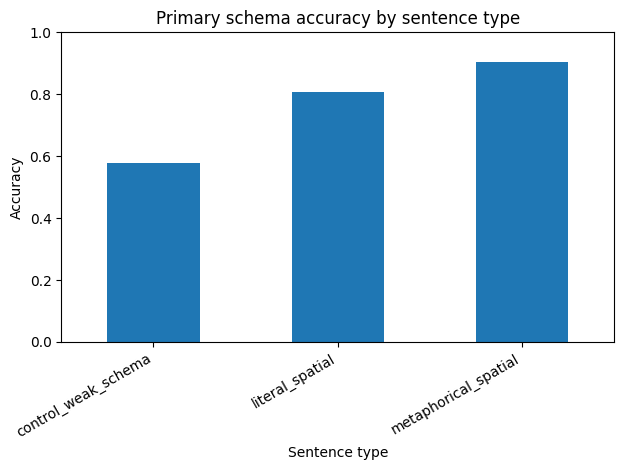

In [6]:
plot_df = by_sentence_type.dropna(subset=["schema_accuracy"]).copy()
ax = plot_df.plot(kind="bar", x="sentence_type", y="schema_accuracy", legend=False)
ax.set_title("Primary schema accuracy by sentence type")
ax.set_xlabel("Sentence type")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Accuracy by prompt family and sentence type

In [7]:
schema_by_prompt_sentence = (
    schema_df.groupby(["prompt_family", "sentence_type"])
    .apply(lambda g: pd.Series({
        "n_schema": len(g),
        "schema_accuracy": safe_accuracy(g, "main_image_schema", "expected_schema_primary"),
    }))
    .reset_index()
)

lm_by_prompt_sentence = (
    lm_df.groupby(["prompt_family", "sentence_type"])
    .apply(lambda g: pd.Series({
        "n_lm": len(g),
        "literal_metaphorical_accuracy": safe_accuracy(g, "literal_or_metaphorical", "expected_literal_or_metaphorical"),
    }))
    .reset_index()
)

by_prompt_sentence = schema_by_prompt_sentence.merge(
    lm_by_prompt_sentence,
    on=["prompt_family", "sentence_type"],
    how="outer",
)
display_compact_df(by_prompt_sentence)
display_gpt_interpretation(by_prompt_sentence, title="Accuracy by prompt family and sentence type", cache_key="v2_02_accuracy_by_prompt_family_and_sentence_type")

,prompt_family,sentence_type,n_schema,schema_accuracy,n_lm,literal_metaphorical_accuracy
0,direct_schema,control_weak_schema,578.000000,0.441176,594.000000,0.008418
1,direct_schema,literal_spatial,595.000000,0.825210,603.000000,1.000000
2,direct_schema,metaphorical_spatial,596.000000,0.912752,603.000000,0.998342
3,structured_role_based,control_weak_schema,594.000000,0.713805,594.000000,0.611111
4,structured_role_based,literal_spatial,603.000000,0.792703,603.000000,0.985075
5,structured_role_based,metaphorical_spatial,603.000000,0.898839,603.000000,1.000000


### GPT interpretation: Accuracy by prompt family and sentence type

- For literal and metaphorical spatial sentences, both structured prompt families perform strongly: schema accuracy is high (≈0.79–0.91) and literal/metaphorical accuracy is near ceiling (≈0.99–1.00).

- Metaphorical spatial cases show the strongest schema performance overall, especially for `direct_schema` (0.9128) and `structured_role_based` (0.8988), suggesting that image-schema prompting is effective for these items.

- Control weak-schema sentences are much harder. `direct_schema` performs poorly on literal/metaphorical classification for controls (0.0084), while `structured_role_based` is substantially better (0.6111), though still far below performance on spatial items.

- The differing `n_schema` and `n_lm` values indicate that records were filtered by separate usability flags; partial records may still validly contribute to one metric if the relevant flag is true.

- Methodologically, JSON/parse quality should be assessed mainly for `direct_schema` and `structured_role_based`; naive free-text outputs, if present elsewhere as `free_text_unparsed`, should be treated as expected baseline behaviour, not parse failure.

Overall, the results are consistent with the claim that structured image-schema prompting can provide a useful intermediate representation for spatial interpretation, especially for literal and metaphorical spatial sentences. However, the weaker control performance cautions against overclaiming general semantic understanding or embodied cognition in the model.

'- For literal and metaphorical spatial sentences, both structured prompt families perform strongly: schema accuracy is high (≈0.79–0.91) and literal/metaphorical accuracy is near ceiling (≈0.99–1.00).\n\n- Metaphorical spatial cases show the strongest schema performance overall, especially for `direct_schema` (0.9128) and `structured_role_based` (0.8988), suggesting that image-schema prompting is effective for these items.\n\n- Control weak-schema sentences are much harder. `direct_schema` performs poorly on literal/metaphorical classification for controls (0.0084), while `structured_role_based` is substantially better (0.6111), though still far below performance on spatial items.\n\n- The differing `n_schema` and `n_lm` values indicate that records were filtered by separate usability flags; partial records may still validly contribute to one metric if the relevant flag is true.\n\n- Methodologically, JSON/parse quality should be assessed mainly for `direct_schema` and `structured_rol

## Accuracy by expected schema family

In [8]:
schema_acc_by_schema = (
    schema_df.groupby("expected_schema_primary")
    .apply(lambda g: pd.Series({
        "n_schema": len(g),
        "schema_accuracy": safe_accuracy(g, "main_image_schema", "expected_schema_primary"),
    }))
    .reset_index()
)

lm_acc_by_schema = (
    lm_df.groupby("expected_schema_primary")
    .apply(lambda g: pd.Series({
        "n_lm": len(g),
        "literal_metaphorical_accuracy": safe_accuracy(g, "literal_or_metaphorical", "expected_literal_or_metaphorical"),
    }))
    .reset_index()
)

by_schema = schema_acc_by_schema.merge(lm_acc_by_schema, on="expected_schema_primary", how="outer")
by_schema = by_schema.sort_values(["schema_accuracy", "n_schema"], ascending=[False, False], na_position="last")
display_compact_df(by_schema)
display_gpt_interpretation(by_schema, title="Accuracy by expected image-schema family", cache_key="v2_02_accuracy_by_expected_schema_family")

,expected_schema_primary,n_schema,schema_accuracy,n_lm,literal_metaphorical_accuracy
3,NONE,1172.000000,nan,1188.000000,0.309764
1,CONTAINER,413.000000,nan,414.000000,1.000000
4,SOURCE_PATH_GOAL,412.000000,nan,414.000000,0.997585
0,BLOCKAGE,396.000000,nan,396.000000,0.984848
5,SUPPORT_BALANCE,394.000000,nan,396.000000,0.992424
2,FORCE,391.000000,nan,396.000000,1.000000
6,VERTICALITY,391.000000,nan,396.000000,1.000000


### GPT interpretation: Accuracy by expected image-schema family

- The table indicates very high literal/metaphorical classification accuracy for sentences with an expected image-schema family: CONTAINER, FORCE, and VERTICALITY reach 1.00, while SOURCE_PATH_GOAL, BLOCKAGE, and SUPPORT_BALANCE are also near ceiling.

- The NONE/control group is much lower, with literal/metaphorical/control accuracy of 0.3098. This suggests that weak-schema control items were substantially harder or were treated inconsistently by the evaluated prompts/model.

- Schema accuracy is not interpretable from this table because all `schema_accuracy` values are `nan`. This likely means no records were usable for that metric under `usable_for_schema_accuracy == True`, or schema scoring was not available in this aggregation.

- Methodologically, this table should not be read as evidence about JSON parsing quality. Naive prompt outputs may appear as `free_text_unparsed`, but that is expected baseline behaviour, not a parsing failure; JSON conformity should be assessed separately for the structured prompt families.

Overall, the results are consistent with structured image-schema-related prompting supporting strong literal/metaphorical classification for schema-bearing items, but they do not by themselves demonstrate accurate schema identification or embodied cognition. The main caution is that semantic accuracy, schema accuracy, and parse coverage must be evaluated as separate metrics using the appropriate usability flags.

'- The table indicates very high literal/metaphorical classification accuracy for sentences with an expected image-schema family: CONTAINER, FORCE, and VERTICALITY reach 1.00, while SOURCE_PATH_GOAL, BLOCKAGE, and SUPPORT_BALANCE are also near ceiling.\n\n- The NONE/control group is much lower, with literal/metaphorical/control accuracy of 0.3098. This suggests that weak-schema control items were substantially harder or were treated inconsistently by the evaluated prompts/model.\n\n- Schema accuracy is not interpretable from this table because all `schema_accuracy` values are `nan`. This likely means no records were usable for that metric under `usable_for_schema_accuracy == True`, or schema scoring was not available in this aggregation.\n\n- Methodologically, this table should not be read as evidence about JSON parsing quality. Naive prompt outputs may appear as `free_text_unparsed`, but that is expected baseline behaviour, not a parsing failure; JSON conformity should be assessed sep

## Schema confusion matrix

In [9]:
schema_confusion = pd.crosstab(
    schema_df["expected_schema_primary"],
    schema_df["main_image_schema"],
    rownames=["gold"],
    colnames=["predicted"],
    dropna=False,
)
display_compact_df(schema_confusion.reset_index(), max_rows=100)
display_gpt_interpretation(schema_confusion.reset_index(), title="Primary schema confusion matrix", cache_key="v2_02_schema_confusion_matrix", max_rows=50)

predicted,gold,BLOCKAGE,CONTAINER,FORCE,NONE,SOURCE_PATH_GOAL,SUPPORT_BALANCE,VERTICALITY
0,BLOCKAGE,386,0,10,0,0,0,0
1,CONTAINER,0,349,0,0,63,0,1
2,FORCE,0,0,330,0,51,0,10
3,NONE,12,214,80,679,172,2,13
4,SOURCE_PATH_GOAL,0,3,0,0,409,0,0
5,SUPPORT_BALANCE,0,0,62,0,1,323,8
6,VERTICALITY,0,2,0,0,113,18,258


### GPT interpretation: Primary schema confusion matrix

- Overall primary-schema accuracy is fairly strong: 2,734/3,569 correct, about 76.6% across all usable schema-accuracy records.
- Literal/metaphorical schema classes are mostly recovered well, especially SOURCE_PATH_GOAL, BLOCKAGE, CONTAINER, FORCE, and SUPPORT_BALANCE.
- The main weakness is the NONE/control class: only 679/1,172 controls are labelled NONE, with many over-interpreted as CONTAINER, SOURCE_PATH_GOAL, or FORCE. This suggests reduced specificity for weak-schema sentences.
- Several systematic confusions are visible: VERTICALITY is often predicted as SOURCE_PATH_GOAL, SUPPORT_BALANCE as FORCE, and CONTAINER/FORCE sometimes as SOURCE_PATH_GOAL.
- Methodologically, this matrix reflects semantic schema classification on records usable for schema accuracy; it should not be read as raw parsing quality. Naive free-text outputs, if present elsewhere as `free_text_unparsed`, are expected baseline behaviour, not parsing failures.

In short, the results are consistent with image-schema prompting helping identify many spatial schemas, but they also show over-assignment of schemas to control items and some predictable boundary confusions. The findings should be framed as evidence for a useful intermediate representational prompt layer, not as evidence that the model has embodied cognition.

'- Overall primary-schema accuracy is fairly strong: 2,734/3,569 correct, about 76.6% across all usable schema-accuracy records.\n- Literal/metaphorical schema classes are mostly recovered well, especially SOURCE_PATH_GOAL, BLOCKAGE, CONTAINER, FORCE, and SUPPORT_BALANCE.\n- The main weakness is the NONE/control class: only 679/1,172 controls are labelled NONE, with many over-interpreted as CONTAINER, SOURCE_PATH_GOAL, or FORCE. This suggests reduced specificity for weak-schema sentences.\n- Several systematic confusions are visible: VERTICALITY is often predicted as SOURCE_PATH_GOAL, SUPPORT_BALANCE as FORCE, and CONTAINER/FORCE sometimes as SOURCE_PATH_GOAL.\n- Methodologically, this matrix reflects semantic schema classification on records usable for schema accuracy; it should not be read as raw parsing quality. Naive free-text outputs, if present elsewhere as `free_text_unparsed`, are expected baseline behaviour, not parsing failures.\n\nIn short, the results are consistent with im

## Literal/metaphorical confusion matrix

In [10]:
lm_confusion = pd.crosstab(
    lm_df["expected_literal_or_metaphorical"],
    lm_df["literal_or_metaphorical"],
    rownames=["gold"],
    colnames=["predicted"],
    dropna=False,
)
display_compact_df(lm_confusion.reset_index(), max_rows=100)
display_gpt_interpretation(lm_confusion.reset_index(), title="Literal/metaphorical/control confusion matrix", cache_key="v2_02_lm_confusion_matrix", max_rows=50)

predicted,gold,control,literal,metaphorical
0,control,368,673,147
1,literal,9,1197,0
2,metaphorical,0,1,1205


### GPT interpretation: Literal/metaphorical/control confusion matrix

- The matrix indicates very strong recognition of literal and metaphorical spatial items: literal recall is about 99.3% and metaphorical recall about 99.9%.
- The main weakness is the control class: only 368/1188 controls are labelled as control, while many are interpreted as literal spatial (673) or metaphorical spatial (147).
- This suggests the model/prompt setup is highly sensitive to spatial structure, but may over-assign spatial interpretations to weak-schema control sentences.
- Overall accuracy is about 76.9%, but this is driven down mainly by control false positives rather than literal/metaphorical confusion.
- Methodologically, this table should be interpreted as semantic classification performance using records marked `usable_for_lm_accuracy == True`, not as evidence about JSON parse quality.

In summary, the results are consistent with strong literal/metaphorical spatial discrimination, but a tendency to impose spatial-schema readings on controls. Naive `free_text_unparsed` outputs should not be counted as parsing failures; JSON conformity should be assessed separately for the structured prompt families only. This supports a cautious claim that image-schema prompting may be a useful representational layer, not that the model possesses embodied cognition.

'- The matrix indicates very strong recognition of literal and metaphorical spatial items: literal recall is about 99.3% and metaphorical recall about 99.9%.\n- The main weakness is the control class: only 368/1188 controls are labelled as control, while many are interpreted as literal spatial (673) or metaphorical spatial (147).\n- This suggests the model/prompt setup is highly sensitive to spatial structure, but may over-assign spatial interpretations to weak-schema control sentences.\n- Overall accuracy is about 76.9%, but this is driven down mainly by control false positives rather than literal/metaphorical confusion.\n- Methodologically, this table should be interpreted as semantic classification performance using records marked `usable_for_lm_accuracy == True`, not as evidence about JSON parse quality.\n\nIn summary, the results are consistent with strong literal/metaphorical spatial discrimination, but a tendency to impose spatial-schema readings on controls. Naive `free_text_un

## Accuracy by provider and model

In [11]:
schema_by_model = (
    schema_df.groupby(["provider", "model_id"])
    .apply(lambda g: pd.Series({
        "n_schema": len(g),
        "schema_accuracy": safe_accuracy(g, "main_image_schema", "expected_schema_primary"),
    }))
    .reset_index()
)

lm_by_model = (
    lm_df.groupby(["provider", "model_id"])
    .apply(lambda g: pd.Series({
        "n_lm": len(g),
        "literal_metaphorical_accuracy": safe_accuracy(g, "literal_or_metaphorical", "expected_literal_or_metaphorical"),
    }))
    .reset_index()
)

by_model = schema_by_model.merge(lm_by_model, on=["provider", "model_id"], how="outer")
display_compact_df(by_model)
display_gpt_interpretation(by_model, title="Accuracy by provider and model", cache_key="v2_02_accuracy_by_provider_and_model")

,provider,model_id,n_schema,schema_accuracy,n_lm,literal_metaphorical_accuracy
0,anthropic,claude_sonnet_4_6,1200.000000,0.692500,1200.000000,0.790000
1,google,gemini_2_5_flash,1169.000000,0.739949,1200.000000,0.740000
2,openai,openai_gpt_5_4_mini,1200.000000,0.865000,1200.000000,0.778333


### GPT interpretation: Accuracy by provider and model

- **Schema accuracy differs substantially by model:** `openai_gpt_5_4_mini` is highest at **0.865**, followed by `gemini_2_5_flash` at **0.7399** and `claude_sonnet_4_6` at **0.6925**.

- **Literal/metaphorical/control accuracy is closer across models:** Anthropic is slightly highest at **0.79**, OpenAI close behind at **0.7783**, and Google lower at **0.74**.

- **The Google schema result uses fewer records** (`n_schema = 1169` vs. 1200), indicating that some outputs were not usable for schema accuracy, while all models have `n_lm = 1200` for literal/metaphorical/control accuracy.

- **Methodological caution:** schema accuracy and literal/metaphorical accuracy are not measuring the same thing; a model can be strong at structured schema identification without being best on broader sentence-type interpretation.

- **Parsing caution:** naive free-text outputs should not be treated as parse failures; JSON conformity should mainly be assessed for direct-schema and structured-role prompt families.

Overall, these results suggest that OpenAI performs best on the structured image-schema task, while Anthropic is marginally strongest on literal/metaphorical/control classification. The findings are consistent with image-schema prompting being a useful representational layer, but they should not be interpreted as evidence that the models possess embodied cognition.

'- **Schema accuracy differs substantially by model:** `openai_gpt_5_4_mini` is highest at **0.865**, followed by `gemini_2_5_flash` at **0.7399** and `claude_sonnet_4_6` at **0.6925**.\n\n- **Literal/metaphorical/control accuracy is closer across models:** Anthropic is slightly highest at **0.79**, OpenAI close behind at **0.7783**, and Google lower at **0.74**.\n\n- **The Google schema result uses fewer records** (`n_schema = 1169` vs. 1200), indicating that some outputs were not usable for schema accuracy, while all models have `n_lm = 1200` for literal/metaphorical/control accuracy.\n\n- **Methodological caution:** schema accuracy and literal/metaphorical accuracy are not measuring the same thing; a model can be strong at structured schema identification without being best on broader sentence-type interpretation.\n\n- **Parsing caution:** naive free-text outputs should not be treated as parse failures; JSON conformity should mainly be assessed for direct-schema and structured-role 

## Save summary tables

In [12]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
by_sentence_type.to_csv(OUTPUT_DIR / "analysis_by_sentence_type.csv", index=False)
by_prompt_sentence.to_csv(OUTPUT_DIR / "analysis_by_prompt_sentence_type.csv", index=False)
by_schema.to_csv(OUTPUT_DIR / "analysis_by_schema_family.csv", index=False)
by_model.to_csv(OUTPUT_DIR / "analysis_by_model.csv", index=False)
print(f"Wrote analysis CSVs to: {OUTPUT_DIR}")

Wrote analysis CSVs to: /Users/Shared/image_schema_llm_project/data/outputs
